<a href="https://colab.research.google.com/github/uddipta-deka/multiclass-brain-tumor-detection/blob/main/notebooks/2_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [10]:
BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"
TRAIN_PATH = os.path.join(BASE_PATH, "dataset", "Training")
TEST_PATH = os.path.join(BASE_PATH, "dataset", "Testing")

In [11]:
# Image Configuration (Based on EDA finding)
IMG_SIZE = (224, 224)
CHANNELS = 3

BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

NUM_CLASSES = 4 ## Glioma, Meningioma, No Tumor, Pituitary

Input Shape ($224 \times 224$):
Standardized resolution to ensure compatibility with future Transfer Learning architectures (ResNet50).

Batch Size ($32$): Balanced to optimize GPU memory usage while maintaining stable gradient estimates.

Learning Rate ($0.001$): Standard starting point for the Adam optimizer to ensure smooth convergence.
.

In [12]:
train_datagen = ImageDataGenerator(
 rescale=1./255,
 validation_split=0.2
)

test_datagen = ImageDataGenerator(
rescale=1./255
)

# 2. Training Subset
train_generator = train_datagen.flow_from_directory(
TRAIN_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training'
)

# 3. Validation Subset
val_generator = train_datagen.flow_from_directory(
TRAIN_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation'
)

# 4. Final Test Set
test_generator = test_datagen.flow_from_directory(
TEST_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [13]:
from tensorflow.keras import layers, models

In [16]:
def baseline_model():
    model = models.Sequential([
        #  First Layer: Edge Detection

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        #  Second Layer: Shape Detection

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        #  Third Layer: Complex Feature Detection

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),


        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        #Output Layer
        layers.Dense(4, activation='softmax')
    ])

    return model


model = baseline_model()


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(os.path.join(SAVE_PATH, 'baseline_model.keras'), save_best_only=True)
]


history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1533s 11s/step - accuracy: 0.7040 - loss: 0.7477 - val_accuracy: 0.8384 - val_loss: 0.4610
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 510s 4s/step - accuracy: 0.8266 - loss: 0.4438 - val_accuracy: 0.8607 - val_loss: 0.3573
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 511s 4s/step - accuracy: 0.8917 - loss: 0.3006 - val_accuracy: 0.8804 - val_loss: 0.3328
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.9158 - loss: 0.2351 - val_accuracy: 0.8955 - val_loss: 0.3126
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.9393 - loss: 0.1629 - val_accuracy: 0.9241 - val_loss: 0.2244
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 506s 4s/step - accuracy: 0.9525 - loss: 0.1312 - val_accuracy: 0.9330 - val_loss: 0.2087
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 512s 4s/step - accuracy: 0.9612 - loss: 0.1077 - val_accuracy: 0.9196 - val_loss: 0.2571
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 509s 4s/step - accuracy: 0.9679 - loss: 0.0835 - val_ac

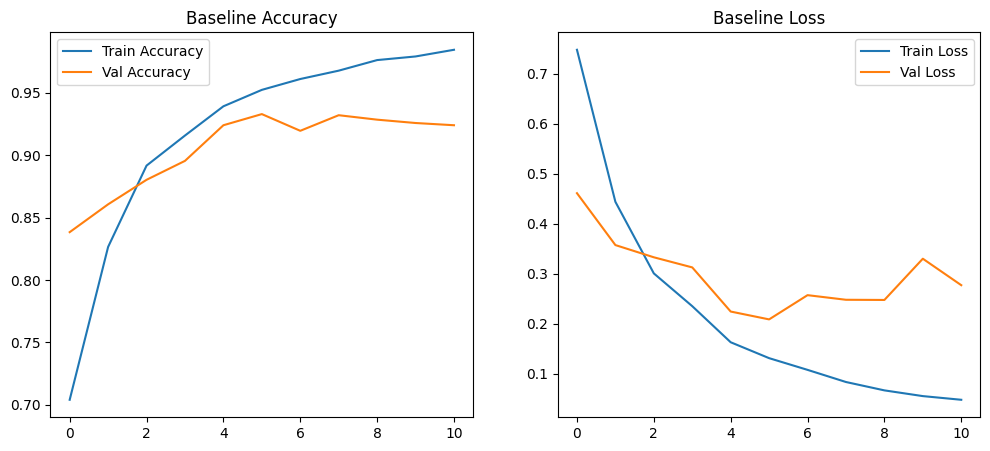

In [18]:
# Plot Training vs Validation Results
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss')
plt.legend()

plt.show()